linki:
https://www.geeksforgeeks.org/
https://www.geeksforgeeks.org/machine-learning/cross-validation-machine-learning/   
https://medium.com/@gjeevan/understanding-macro-micro-and-weighted-f1-scores-with-intuition-and-examples-20799a6a170d
https://www.statology.org/how-use-gridsearchcv-scikit-learn-for-optimizing-model-parameters/

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, ShuffleSplit
from sklearn.model_selection import GridSearchCV, KFold

In [3]:
rng = 1234

In [4]:
df = pd.read_csv("ortodoncja.csv")
df

,9_SN/MP,9_Facial axis,9_Y-axis,9_Mn Base angle,9_Mn Ramus Angle,9_SNPog,9_SNB,9_SNA,9_SN/PP,9_ANB,9_AFH:PFH,9_PgNB,9_beta angle,12_SN/MP,12_Facial axis,12_Y-axis,12_Mn Base angle,12_Mn Ramus Angle,12_SNPog,12_SNB,12_SNA,12_SN/PP,12_ANB,12_AFH:PFH,12_PgNB,12_beta angle,growth direction
0,28.882655,87.411884,66.908260,0.415477,111.114850,75.585670,74.142998,80.118387,13.603083,-5.975389,1.414086,1.442672,22.508486,27.909820,86.576894,65.704419,1.685919,116.585770,77.233907,76.042877,80.645978,10.223444,-4.603101,1.416613,1.191030,22.220111,horizontal
1,35.410983,90.714247,67.379392,2.480978,123.868967,77.719090,75.980740,77.756093,6.041252,-1.775353,1.461818,1.738350,19.066329,33.743739,90.349278,67.648119,2.141797,120.371230,79.480178,77.289118,83.189766,2.538123,-5.900647,1.500294,2.191060,18.056378,horizontal
2,27.952347,90.827615,65.432107,2.277330,119.958531,78.909186,77.545863,81.804363,4.403767,-4.258501,1.343757,1.363323,21.822947,27.659934,89.636694,65.091970,3.492217,117.981833,80.125853,78.238824,81.127838,4.228677,-2.889014,1.341424,1.887029,22.169193,horizontal
3,25.138396,82.195544,59.619544,2.539409,118.323917,80.678309,78.714113,86.651762,1.864515,-7.937649,1.356391,1.964196,22.037847,24.174110,81.822303,59.646321,3.436016,118.071540,82.430061,80.259569,88.624746,-0.890545,-8.365177,1.355916,2.170492,21.251448,horizontal
4,33.761656,90.240915,65.960066,2.929263,126.728619,76.907767,76.334661,83.908674,14.651077,-7.574013,1.459953,0.573105,18.660648,33.334275,90.437338,65.913581,2.824466,128.441180,76.907972,76.362007,83.320338,13.187977,-6.958331,1.459762,0.545964,18.528448,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441,35.178582,88.026303,67.291160,2.325724,124.614357,76.842483,76.751712,83.320475,6.472243,-6.568763,1.488824,0.090771,19.000121,32.522318,88.658129,66.424702,3.381613,124.063284,78.847063,78.671476,83.623443,6.967580,-4.951967,1.412868,0.175587,20.030570,normal
442,34.299938,87.339586,65.735458,2.328455,123.087223,77.248174,75.250947,81.604217,5.806036,-6.353270,1.510913,1.997227,17.430982,36.107656,87.140464,66.459559,2.939633,122.056916,77.897540,76.621034,82.268413,7.740249,-5.647379,1.538280,1.276505,17.196355,normal
443,30.186415,85.332030,63.742767,2.619851,116.289956,79.646663,77.716725,79.289320,3.550770,-1.572595,1.460223,1.929938,18.560427,29.119946,85.462801,63.697252,3.233139,113.778421,79.943289,77.827477,79.583359,5.638938,-1.755881,1.463132,2.115812,19.865993,horizontal
444,43.308352,96.535111,71.936381,0.996169,136.078325,73.914911,74.199658,81.212461,2.141273,-7.012803,1.570766,-0.284747,15.731431,41.557741,99.684510,71.522675,1.345894,132.275846,75.637836,76.037974,83.270586,1.811463,-7.232613,1.512700,-0.400137,15.510283,normal


In [5]:
direction_dict = {"horizontal": 0, "normal": 1, "vertical": 2}
df["growth direction"] = df["growth direction"].map(direction_dict)
df

,9_SN/MP,9_Facial axis,9_Y-axis,9_Mn Base angle,9_Mn Ramus Angle,9_SNPog,9_SNB,9_SNA,9_SN/PP,9_ANB,9_AFH:PFH,9_PgNB,9_beta angle,12_SN/MP,12_Facial axis,12_Y-axis,12_Mn Base angle,12_Mn Ramus Angle,12_SNPog,12_SNB,12_SNA,12_SN/PP,12_ANB,12_AFH:PFH,12_PgNB,12_beta angle,growth direction
0,28.882655,87.411884,66.908260,0.415477,111.114850,75.585670,74.142998,80.118387,13.603083,-5.975389,1.414086,1.442672,22.508486,27.909820,86.576894,65.704419,1.685919,116.585770,77.233907,76.042877,80.645978,10.223444,-4.603101,1.416613,1.191030,22.220111,0
1,35.410983,90.714247,67.379392,2.480978,123.868967,77.719090,75.980740,77.756093,6.041252,-1.775353,1.461818,1.738350,19.066329,33.743739,90.349278,67.648119,2.141797,120.371230,79.480178,77.289118,83.189766,2.538123,-5.900647,1.500294,2.191060,18.056378,0
2,27.952347,90.827615,65.432107,2.277330,119.958531,78.909186,77.545863,81.804363,4.403767,-4.258501,1.343757,1.363323,21.822947,27.659934,89.636694,65.091970,3.492217,117.981833,80.125853,78.238824,81.127838,4.228677,-2.889014,1.341424,1.887029,22.169193,0
3,25.138396,82.195544,59.619544,2.539409,118.323917,80.678309,78.714113,86.651762,1.864515,-7.937649,1.356391,1.964196,22.037847,24.174110,81.822303,59.646321,3.436016,118.071540,82.430061,80.259569,88.624746,-0.890545,-8.365177,1.355916,2.170492,21.251448,0
4,33.761656,90.240915,65.960066,2.929263,126.728619,76.907767,76.334661,83.908674,14.651077,-7.574013,1.459953,0.573105,18.660648,33.334275,90.437338,65.913581,2.824466,128.441180,76.907972,76.362007,83.320338,13.187977,-6.958331,1.459762,0.545964,18.528448,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441,35.178582,88.026303,67.291160,2.325724,124.614357,76.842483,76.751712,83.320475,6.472243,-6.568763,1.488824,0.090771,19.000121,32.522318,88.658129,66.424702,3.381613,124.063284,78.847063,78.671476,83.623443,6.967580,-4.951967,1.412868,0.175587,20.030570,1
442,34.299938,87.339586,65.735458,2.328455,123.087223,77.248174,75.250947,81.604217,5.806036,-6.353270,1.510913,1.997227,17.430982,36.107656,87.140464,66.459559,2.939633,122.056916,77.897540,76.621034,82.268413,7.740249,-5.647379,1.538280,1.276505,17.196355,1
443,30.186415,85.332030,63.742767,2.619851,116.289956,79.646663,77.716725,79.289320,3.550770,-1.572595,1.460223,1.929938,18.560427,29.119946,85.462801,63.697252,3.233139,113.778421,79.943289,77.827477,79.583359,5.638938,-1.755881,1.463132,2.115812,19.865993,0
444,43.308352,96.535111,71.936381,0.996169,136.078325,73.914911,74.199658,81.212461,2.141273,-7.012803,1.570766,-0.284747,15.731431,41.557741,99.684510,71.522675,1.345894,132.275846,75.637836,76.037974,83.270586,1.811463,-7.232613,1.512700,-0.400137,15.510283,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 446 entries, 0 to 445
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   9_SN/MP            446 non-null    float64
 1   9_Facial axis      446 non-null    float64
 2   9_Y-axis           446 non-null    float64
 3   9_Mn Base angle    446 non-null    float64
 4   9_Mn Ramus Angle   446 non-null    float64
 5   9_SNPog            446 non-null    float64
 6   9_SNB              446 non-null    float64
 7   9_SNA              446 non-null    float64
 8   9_SN/PP            446 non-null    float64
 9   9_ANB              446 non-null    float64
 10  9_AFH:PFH          446 non-null    float64
 11  9_PgNB             446 non-null    float64
 12  9_beta angle       446 non-null    float64
 13  12_SN/MP           446 non-null    float64
 14  12_Facial axis     446 non-null    float64
 15  12_Y-axis          446 non-null    float64
 16  12_Mn Base angle   446 non-null    fl

In [7]:
df.isnull().sum()

9_SN/MP              0
9_Facial axis        0
9_Y-axis             0
9_Mn Base angle      0
9_Mn Ramus Angle     0
9_SNPog              0
9_SNB                0
9_SNA                0
9_SN/PP              0
9_ANB                0
9_AFH:PFH            0
9_PgNB               0
9_beta angle         0
12_SN/MP             0
12_Facial axis       0
12_Y-axis            0
12_Mn Base angle     0
12_Mn Ramus Angle    0
12_SNPog             0
12_SNB               0
12_SNA               0
12_SN/PP             0
12_ANB               0
12_AFH:PFH           0
12_PgNB              0
12_beta angle        0
growth direction     0
dtype: int64

In [8]:
df.describe()

,9_SN/MP,9_Facial axis,9_Y-axis,9_Mn Base angle,9_Mn Ramus Angle,9_SNPog,9_SNB,9_SNA,9_SN/PP,9_ANB,9_AFH:PFH,9_PgNB,9_beta angle,12_SN/MP,12_Facial axis,12_Y-axis,12_Mn Base angle,12_Mn Ramus Angle,12_SNPog,12_SNB,12_SNA,12_SN/PP,12_ANB,12_AFH:PFH,12_PgNB,12_beta angle,growth direction
count,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000
mean,33.315033,88.428514,66.637249,1.946258,122.568512,77.290273,76.339302,80.718170,7.204316,-4.378868,1.466034,0.950747,20.103708,32.336289,88.232604,66.535953,2.569964,121.245704,78.450767,77.290843,81.212121,7.165841,-3.921278,1.446325,1.160148,20.801461,0.623318
std,4.664109,3.559692,3.134645,1.407175,5.581123,3.140499,3.046515,3.404900,3.203708,2.058331,0.077032,0.711865,2.402912,4.723713,3.661869,3.175055,1.397803,5.566098,3.130976,3.089604,3.452230,3.103847,2.158409,0.075403,0.727387,2.384866,0.554284
min,19.569295,75.471874,55.264537,-1.855797,106.273890,68.094393,67.770015,72.707404,-3.371575,-9.725989,1.230321,-1.131231,12.671876,19.708797,75.827096,56.529929,-1.592408,104.789965,70.481570,70.187880,72.099648,-1.292949,-10.293067,1.244515,-1.068884,13.056881,0.000000
25%,30.083138,85.978142,64.481794,0.921260,118.904444,75.135247,74.086700,78.469479,5.089419,-5.792613,1.412721,0.486863,18.377807,29.098782,85.586465,64.433521,1.640817,117.373239,76.424090,75.281835,78.721307,5.238621,-5.370657,1.393239,0.656741,19.067425,0.000000
50%,33.446964,88.256898,66.430186,1.937554,122.855447,77.308051,76.161821,80.618224,7.085342,-4.480021,1.469337,0.976407,20.087922,32.266668,87.972526,66.309870,2.541229,121.047114,78.337574,77.129546,81.119388,7.262479,-4.014321,1.445952,1.162735,20.820688,1.000000
75%,36.433746,90.737761,68.700723,2.861721,126.266211,79.331829,78.261735,82.869704,9.165975,-2.935589,1.516694,1.435451,21.571410,35.812327,90.729237,68.609288,3.437915,125.040958,80.338232,79.223116,83.389647,9.323639,-2.372826,1.501029,1.671685,22.318562,1.000000
max,49.286542,99.677516,75.115567,6.200186,137.616824,86.862239,84.787099,93.149888,18.750681,0.945465,1.703877,3.559659,30.414008,45.960865,99.772896,74.717246,6.987558,139.166983,88.868366,86.982279,92.429272,15.053215,2.579310,1.650425,3.176099,29.655680,2.000000


# W KODZIE PONIŻEJ NIE ROBIĆ BOX PLOTA DLA GROWTH DIRECTION I ZMIENIĆ TROCHĘ KOD

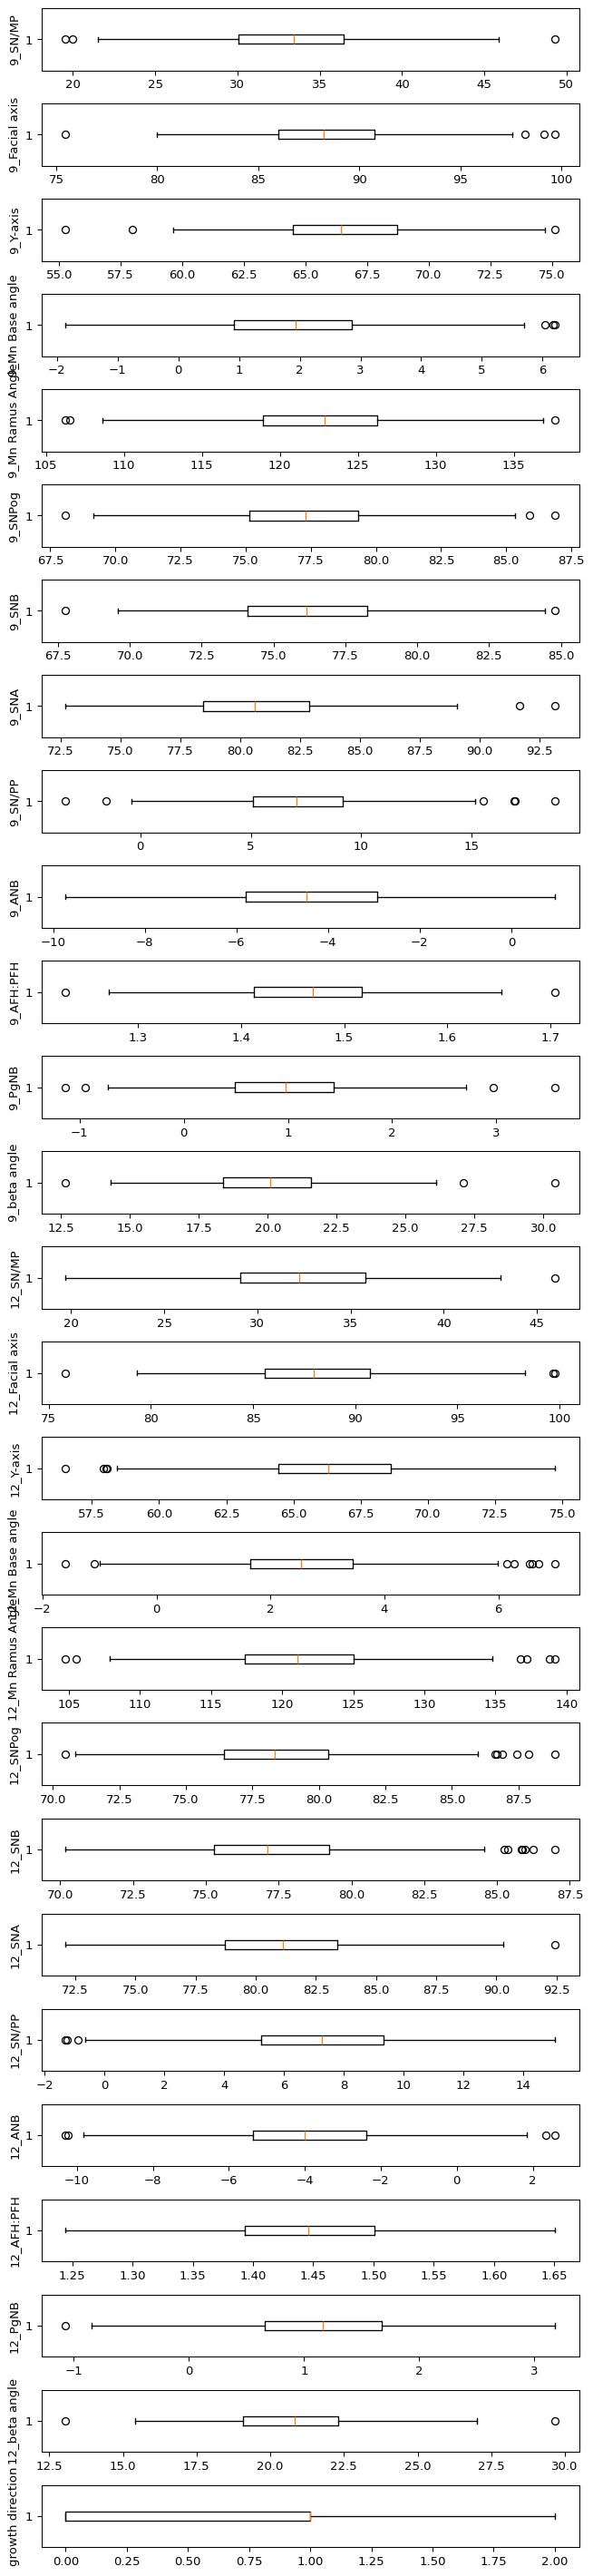

In [9]:
# https://www.geeksforgeeks.org/data-analysis/data-preprocessing-machine-learning-python/
fig, axs = plt.subplots(len(df.columns), 1, figsize=(7, 30), dpi=95)
for i, col in enumerate(df.columns):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)
fig.tight_layout()
plt.show()

In [10]:
description = df.describe()
description

for column in df.columns:
    info_column = description[column]
    q1 = info_column["25%"]
    q3 = info_column["75%"]
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    for idx, value in enumerate(df[column]):
        if (value < lower_bound):
            df.at[idx, column] = lower_bound
        elif (value > upper_bound):
            df.at[idx, column] = upper_bound

df.describe()

,9_SN/MP,9_Facial axis,9_Y-axis,9_Mn Base angle,9_Mn Ramus Angle,9_SNPog,9_SNB,9_SNA,9_SN/PP,9_ANB,9_AFH:PFH,9_PgNB,9_beta angle,12_SN/MP,12_Facial axis,12_Y-axis,12_Mn Base angle,12_Mn Ramus Angle,12_SNPog,12_SNB,12_SNA,12_SN/PP,12_ANB,12_AFH:PFH,12_PgNB,12_beta angle,growth direction
count,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000
mean,33.311077,88.428475,66.643967,1.943797,122.574340,77.288590,76.338834,80.704965,7.195100,-4.378868,1.466024,0.949368,20.094993,32.336114,88.231426,66.540665,2.565757,121.236082,78.434901,77.278397,81.207554,7.167535,-3.921026,1.446325,1.160604,20.798487,0.623318
std,4.631137,3.513693,3.112282,1.400117,5.561164,3.126258,3.044561,3.364538,3.138873,2.058331,0.076657,0.704847,2.360503,4.723208,3.630324,3.161599,1.378930,5.518871,3.086000,3.055394,3.438677,3.099334,2.148815,0.075403,0.726050,2.359384,0.554284
min,20.557225,78.838713,58.153402,-1.855797,107.861794,68.840374,67.824147,72.707404,-1.025417,-9.725989,1.256760,-0.936020,13.587402,19.708797,77.872307,58.169870,-1.054830,105.871661,70.552876,70.187880,72.099648,-0.888905,-9.867403,1.244515,-0.865676,14.190720,0.000000
25%,30.083138,85.978142,64.481794,0.921260,118.904444,75.135247,74.086700,78.469479,5.089419,-5.792613,1.412721,0.486863,18.377807,29.098782,85.586465,64.433521,1.640817,117.373239,76.424090,75.281835,78.721307,5.238621,-5.370657,1.393239,0.656741,19.067425,0.000000
50%,33.446964,88.256898,66.430186,1.937554,122.855447,77.308051,76.161821,80.618224,7.085342,-4.480021,1.469337,0.976407,20.087922,32.266668,87.972526,66.309870,2.541229,121.047114,78.337574,77.129546,81.119388,7.262479,-4.014321,1.445952,1.162735,20.820688,1.000000
75%,36.433746,90.737761,68.700723,2.861721,126.266211,79.331829,78.261735,82.869704,9.165975,-2.935589,1.516694,1.435451,21.571410,35.812327,90.729237,68.609288,3.437915,125.040958,80.338232,79.223116,83.389647,9.323639,-2.372826,1.501029,1.671685,22.318562,1.000000
max,45.959659,97.877190,75.029116,5.772412,137.308862,85.626701,84.524288,89.470043,15.280811,0.945465,1.672654,2.858334,26.361815,45.882646,98.443395,74.717246,6.133562,136.542537,86.209446,85.135038,90.392157,15.053215,2.123920,1.650425,3.176099,27.195266,2.000000


In [11]:
df_training, df_test = train_test_split(df, train_size=0.7, random_state=rng)
df_training = df_training.reset_index(drop=True)
print(df_training.shape)

(312, 27)


In [12]:
print(df_training.corr())

                    9_SN/MP  9_Facial axis  ...  12_beta angle  growth direction
9_SN/MP            1.000000       0.646204  ...      -0.691115          0.503646
9_Facial axis      0.646204       1.000000  ...      -0.226875          0.340506
9_Y-axis           0.773002       0.817994  ...      -0.254396          0.367923
9_Mn Base angle   -0.070070      -0.137754  ...       0.010402         -0.103203
9_Mn Ramus Angle   0.605632       0.159190  ...      -0.758653          0.377406
9_SNPog           -0.694280      -0.559762  ...       0.261462         -0.293560
9_SNB             -0.624810      -0.475164  ...       0.225575         -0.186017
9_SNA             -0.471736      -0.245616  ...       0.223308         -0.060077
9_SN/PP            0.391367       0.316416  ...      -0.075059          0.220835
9_ANB             -0.165497      -0.315963  ...      -0.025749         -0.185706
9_AFH:PFH          0.927356       0.487674  ...      -0.690402          0.457791
9_PgNB            -0.368001 

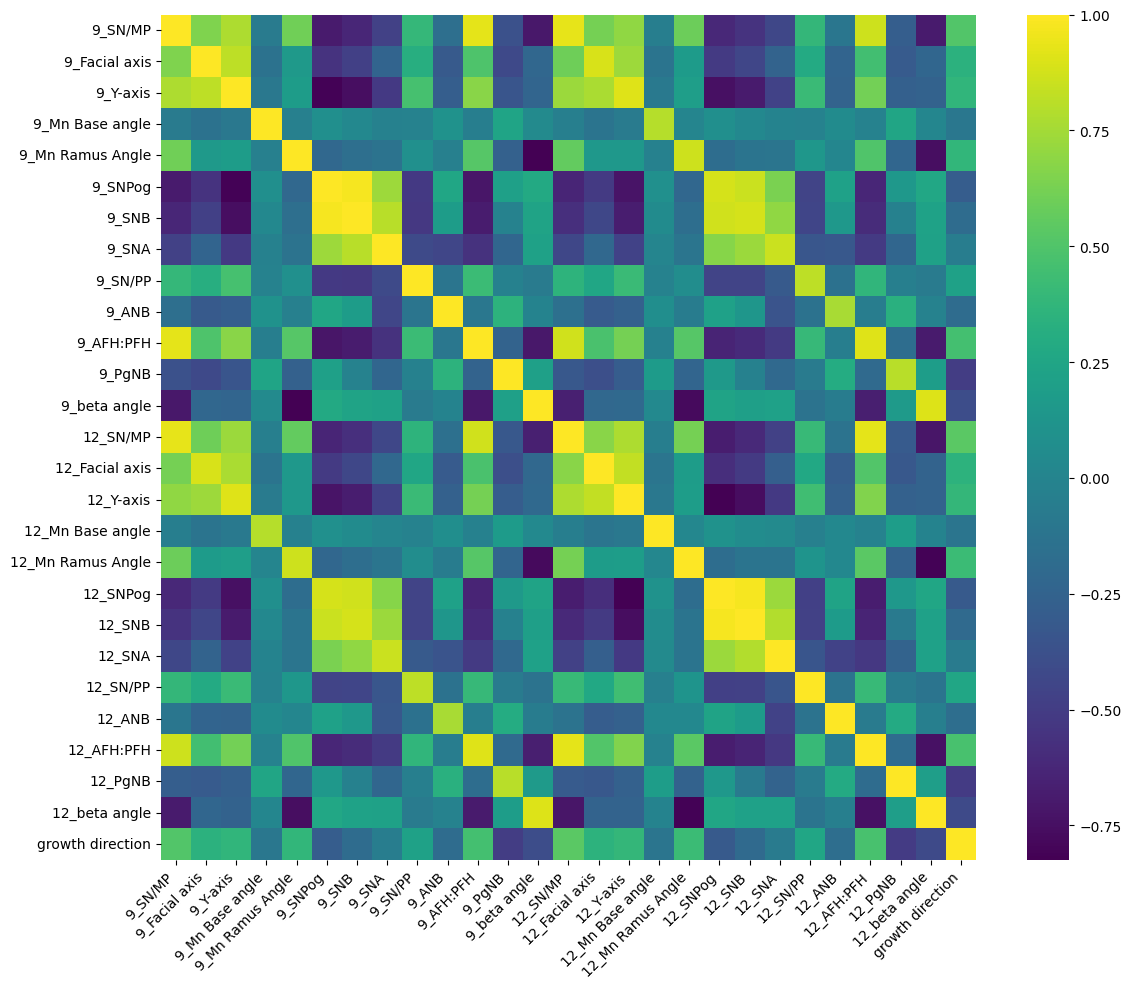

In [13]:
#ai generated
corr = df_training.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=False, ax=ax, cbar=True, cmap='viridis')

ax.set_xticks([i + 0.5 for i in range(len(corr.columns))])
ax.set_yticks([i + 0.5 for i in range(len(corr.index))])

ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.index, rotation=0)

plt.tight_layout()
plt.show()

In [14]:
df_training.drop('9_SNPog', axis=1, inplace=True)
df_training.drop('12_SNPog', axis=1, inplace=True)

df_test.drop('9_SNPog', axis=1, inplace=True)
df_test.drop('12_SNPog', axis=1, inplace=True)

In [15]:
values_occurences = df_training['growth direction'].value_counts()
print(values_occurences)

growth direction
1    172
0    131
2      9
Name: count, dtype: int64


In [16]:
smote = SMOTE(sampling_strategy='not majority', random_state=123)
x_train, y_train = smote.fit_resample(df_training.iloc[:, :-1], df_training.iloc[:, -1])


In [17]:
x_test = df_test.iloc[:, :-1]
y_test = df_test.iloc[:, -1] 

x_test = x_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [18]:
scaler = StandardScaler()

scaler.fit(x_train)
x_train = pd.DataFrame(scaler.transform(x_train), columns=x_train.columns)
x_test = pd.DataFrame(scaler.transform(x_test), columns=x_test.columns)

x_train.describe()

,9_SN/MP,9_Facial axis,9_Y-axis,9_Mn Base angle,9_Mn Ramus Angle,9_SNB,9_SNA,9_SN/PP,9_ANB,9_AFH:PFH,9_PgNB,9_beta angle,12_SN/MP,12_Facial axis,12_Y-axis,12_Mn Base angle,12_Mn Ramus Angle,12_SNB,12_SNA,12_SN/PP,12_ANB,12_AFH:PFH,12_PgNB,12_beta angle
count,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02
mean,-3.029446e-16,-2.354706e-15,-4.213684e-15,1.394234e-16,-8.262125e-16,1.624885e-15,-3.456322e-15,-5.508083e-17,-6.885104e-17,-1.569804e-15,1.377021e-17,6.058892e-16,-2.203233e-16,2.630110e-15,1.652425e-16,-1.583574e-16,-1.129157e-15,-1.982910e-15,2.588799e-15,-1.101617e-16,-5.508083e-17,4.681871e-16,-2.203233e-16,1.129157e-15
std,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00
min,-3.004075e+00,-2.735946e+00,-2.688169e+00,-3.137605e+00,-2.951923e+00,-2.905316e+00,-2.351069e+00,-2.934128e+00,-2.788458e+00,-2.776946e+00,-2.595220e+00,-1.714208e+00,-2.863593e+00,-2.571906e+00,-3.004147e+00,-2.727034e+00,-2.946704e+00,-2.318695e+00,-2.556176e+00,-3.044646e+00,-3.112466e+00,-2.739520e+00,-2.817362e+00,-1.619035e+00
25%,-7.811838e-01,-7.928729e-01,-6.751323e-01,-4.757212e-01,-6.051281e-01,-6.154328e-01,-6.690260e-01,-5.780165e-01,-6.869649e-01,-7.526369e-01,-7.582925e-01,-8.254284e-01,-7.683239e-01,-7.661782e-01,-7.370634e-01,-5.944822e-01,-8.277864e-01,-5.592619e-01,-7.258400e-01,-6.741709e-01,-6.505331e-01,-7.733081e-01,-6.335228e-01,-8.824094e-01
50%,2.143994e-01,9.400767e-02,1.202369e-01,1.816173e-02,2.140085e-01,-5.613653e-02,8.355061e-03,-9.450304e-02,-1.288775e-01,1.307872e-01,3.436731e-02,-1.519402e-01,1.636188e-01,2.111058e-02,7.526322e-03,4.597675e-02,9.392862e-02,-1.341064e-01,-1.761891e-01,9.994832e-02,-4.968155e-02,1.593969e-01,1.204122e-02,-1.711297e-01
75%,8.194354e-01,7.358093e-01,5.938566e-01,5.452078e-01,6.426459e-01,4.962938e-01,6.170020e-01,6.479667e-01,7.436232e-01,8.426112e-01,6.848877e-01,7.581807e-01,8.237394e-01,7.749747e-01,6.869802e-01,6.382726e-01,8.238144e-01,5.937464e-01,7.168745e-01,6.699352e-01,7.721978e-01,8.115339e-01,6.715883e-01,7.800184e-01
max,2.252770e+00,2.596694e+00,2.659441e+00,3.218816e+00,2.259051e+00,3.133291e+00,3.062784e+00,2.403532e+00,2.713362e+00,2.207218e+00,2.952145e+00,2.713568e+00,2.257379e+00,2.564907e+00,2.391999e+00,2.487092e+00,2.098919e+00,3.088045e+00,3.175069e+00,2.490063e+00,2.849783e+00,2.137397e+00,2.971582e+00,2.836022e+00


In [36]:
def calculate_metrcs(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    return (accuracy, precision, f1, recall)

def print_metrics(metrics):
    print(f'Accuracy: {metrics[0] * 100:.2f}%')
    print(f'Precision: {metrics[1]:.3f}')
    print(f'F1 score: {metrics[2]:.3f}')
    print(f'Recall: {metrics[3]:.3f}')

In [46]:
estim = RandomForestClassifier(random_state=rng)
kf = KFold(n_splits=5, shuffle=True, random_state=rng)

params_grid = {
    'n_estimators': [60, 120, 250, 300, 350, 500],
    'max_depth': [4, 6, 8, 12, 16, None],
    'max_features': [4, 8, 12, 16, 26],
    'min_samples_leaf': [1, 2, 4, 6, 8]
}

forest = GridSearchCV(estimator=estim, param_grid=params_grid, scoring='accuracy', n_jobs=-1)

forest.fit(x_train, y_train)

KeyboardInterrupt: 

In [ ]:
y_pred = forest.predict(x_test)
metrics = calculate_metrcs(y_test, y_pred)
print_metrics(metrics)

Accuracy: 81.34%
Precision: 0.748
F1 score: 0.717
Recall: 0.695


In [19]:
# esimators = [40, 60, 100, 120, 130, 140, 200, 300, 500, 700, 1000]

# for est in esimators:
#     print("Random forest with " + str(est) + " trees")
#     avg = 0.0
#     loops = 30
#     for i in range(0, loops):    
#         forest = RandomForestClassifier(n_estimators=est, random_state=rng)
#         forest.fit(x_train, y_train)
#         y_pred = forest.predict(x_test)
#         accuracy = accuracy_score(y_test, y_pred)
#         avg += accuracy
#     avg = avg / loops
#     print(f'Avg accuracy: {avg * 100:.2f}%')

In [20]:
# depths = [2, 4, 6, 8, 10, 15, 20, 30, 40, 50, 80, 100, None]

# for depth in depths:
#     print("Random forest with max depth: " + str(depth))
#     avg = 0.0
#     loops = 30
#     for i in range(0, loops):    
#         forest = RandomForestClassifier(n_estimators=100, random_state=rng, max_depth=depth)
#         forest.fit(x_train, y_train)
#         y_pred = forest.predict(x_test)
#         accuracy = accuracy_score(y_test, y_pred)
#         avg += accuracy
#     avg = avg / loops
#     print(f'Avg accuracy: {avg * 100:.2f}%')

In [21]:
# max_features = [2, 4, 6, 8, 12, 16, 20, 24, 26]

# for maxf in max_features:
#     print("Random forest with max features: " + str(maxf))
#     avg = 0.0
#     loops = 30
#     for i in range(0, loops):    
#         forest = RandomForestClassifier(n_estimators=100, random_state=rng, max_features=maxf)
#         forest.fit(x_train, y_train)
#         y_pred = forest.predict(x_test)
#         accuracy = accuracy_score(y_test, y_pred)
#         avg += accuracy
#     avg = avg / loops
#     print(f'Avg accuracy: {avg * 100:.2f}%')

In [22]:
# min_leafs = [1, 2, 4, 8, 16]

# for minl in min_leafs:
#     print("Random forest with min_samples_leaf: " + str(minl))
#     avg = 0.0
#     loops = 30
#     for i in range(0, loops):    
#         forest = RandomForestClassifier(n_estimators=100, random_state=rng, min_samples_leaf=minl)
#         forest.fit(x_train, y_train)
#         y_pred = forest.predict(x_test)
#         accuracy = accuracy_score(y_test, y_pred)
#         avg += accuracy
#     avg = avg / loops
#     print(f'Avg accuracy: {avg * 100:.2f}%')

In [ ]:
estim = KNeighborsClassifier()
kf = KFold(n_splits=5, shuffle=True, random_state=rng)

params_grid = {
    'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40]
}

neighbors = GridSearchCV(estimator=estim, param_grid=params_grid, scoring='accuracy', n_jobs=-1)
neighbors.fit(x_train, y_train)

In [ ]:
y_pred = neighbors.predict(x_test)
metrics = calculate_metrcs(y_test, y_pred)
print_metrics(metrics)

In [ ]:
estim = LogisticRegression(random_state=rng)
kf = KFold(n_splits=5, shuffle=True, random_state=rng)

logreg = GridSearchCV(estimator=estim, param_grid=params_grid, scoring='accuracy', n_jobs=-1)
logreg.fit(x_train, y_train)

In [ ]:
# logreg = LogisticRegression(random_state=rng)
# logreg.fit(x_train, y_train)
# y_pred = logreg.predict(x_test)
# # accuracy = accuracy_score(y_test, y_pred)
# # print(f'Accuracy: {accuracy * 100:.2f}%')
# metrics = calculate_metrcs(y_test, y_pred)
# print_metrics(metrics)

Accuracy: 75.37%
Precision: 0.702
F1 score: 0.733
Recall: 0.817
